## SHL Audio Scoring Contest: Two-Pipeline Feature Extraction

**Strategy Overview:**
To avoid overfitting on the small training dataset (409 samples), this solution does not directly train a deep neural network on raw audio. Rather, it applies a Dual-Pipeline Feature Extraction methodology to engineer highly interpretable numerical features, which are then handed over to an XGBoost Regressor.

**1. NLP Pipeline (Grammar):**
* Used OpenAI's `faster-whisper` (GPU-accelerated) to transcribe audio to text.
* Analyzed the text with `language-tool-python` to obtain `grammar_errors`, `word_count`, and a general `error_rate`.

**2. Acoustic Pipeline (Fluency):**
* Analyzed the raw waveforms using `librosa`, separating active speaking time and dead air to obtain `silence_ratio` and `speaking_rate` (words/second).

**Interpretability & Validity:**
* The descriptive statistics analysis revealed that the means of the independent and dependent variables differed as intended.
* The XGBoost model utilizes a 5-Fold Cross Validation strategy to ensure robustness.
* Feature Importance graphs (generated below) clearly demonstrate how the model weighs grammatical accuracy against hesitation/pauses to determine the final MOS score, guaranteeing complete interpretability for stakeholders.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_49.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_67_1.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_90.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_77.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_20_1.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_66.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_54.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_106_1.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_42.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_81.wav
/kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test/audio_72.wav
/kaggle/input/competition

In [2]:
import pandas as pd
import os

# Dynamically find the train.csv path to avoid folder name typos
train_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'train.csv':
            train_path = os.path.join(dirname, filename)

if train_path:
    train_df = pd.read_csv(train_path)
    print(f"Success! Training data loaded. Shape: {train_df.shape}")
    display(train_df.head())
else:
    print("Could not find train.csv. Let's double check the folder structure.")

Success! Training data loaded. Shape: (409, 2)


,filename,label
0,audio_173,3.0
1,audio_138,3.0
2,audio_127,2.0
3,audio_95,2.0
4,audio_73,3.5


In [3]:
!pip install faster-whisper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 48.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 42.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 62.7 MB/s eta 0:00:00:00:0100:01


In [6]:
from faster_whisper import WhisperModel
from tqdm.notebook import tqdm
import os

print("Loading Whisper model on GPU...")
model = WhisperModel("base", device="cuda", compute_type="float16")

# 1. Let's hunt down the exact directory containing the files!
audio_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file == 'audio_173.wav': # Looking for our first specific file
            audio_dir = root
            break
    if audio_dir:
        break

if not audio_dir:
    print("CRITICAL ERROR: Could not find the audio files anywhere in /kaggle/input")
else:
    print(f"SUCCESS! Found the exact audio directory at: {audio_dir}")
    
    # 2. Now run the transcription
    transcripts = []
    print(f"Starting transcription for {len(train_df)} files...")

    for index, row in tqdm(train_df.iterrows(), total=len(train_df)):
        fname = str(row['filename'])
        if not fname.endswith('.wav'):
            fname += '.wav'
            
        audio_path = os.path.join(audio_dir, fname)
        
        if os.path.exists(audio_path):
            segments, info = model.transcribe(audio_path, beam_size=5)
            text = " ".join([segment.text for segment in segments])
            transcripts.append(text.strip())
        else:
            print(f"Missing specific file: {fname}")
            transcripts.append("")

    train_df['transcript'] = transcripts
    train_df.to_csv('train_with_transcripts.csv', index=False)

    print("\nSuccess! Transcriptions complete and safely saved.")
    display(train_df.head())

Loading Whisper model on GPU...
SUCCESS! Found the exact audio directory at: /kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/train
Starting transcription for 409 files...


  0%|          | 0/409 [00:00<?, ?it/s]


Success! Transcriptions complete and safely saved.


,filename,label,transcript
0,audio_173,3.0,"My favorite place to visit will be Japan, beca..."
1,audio_138,3.0,"I love to reading on my hobbies as reading, Em..."
2,audio_127,2.0,"Yeah, my favorite place to visit is Tirmala. I..."
3,audio_95,2.0,I am going to tell about my hobby and my hobby...
4,audio_73,3.5,"This is a tough one, so my bestie of my life i..."


In [7]:
!pip install language-tool-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 2.0 MB/s eta 0:00:00


In [8]:
import pandas as pd
import language_tool_python
from tqdm.notebook import tqdm

# Load the transcripts we just saved
train_df = pd.read_csv('train_with_transcripts.csv')

print("Loading Grammar Engine (this takes a moment to boot up on the first run)...")
tool = language_tool_python.LanguageTool('en-US')

grammar_errors = []
word_counts = []
error_rates = []

print("Extracting grammar features...")
# Fill any missing transcripts with empty strings to prevent crashes
transcripts = train_df['transcript'].fillna("").tolist()

for text in tqdm(transcripts):
    if not text.strip():
        # Handle any silent/empty audio files safely
        grammar_errors.append(0)
        word_counts.append(0)
        error_rates.append(0)
        continue
        
    # 1. Count Grammatical Mistakes
    matches = tool.check(text)
    errors = len(matches)
    
    # 2. Count Words
    words = len(text.split())
    
    # 3. Calculate Error Rate (Mistakes per word)
    rate = errors / words if words > 0 else 0
    
    grammar_errors.append(errors)
    word_counts.append(words)
    error_rates.append(rate)

Loading Grammar Engine (this takes a moment to boot up on the first run)...


Extracting grammar features...


  0%|          | 0/409 [00:00<?, ?it/s]

In [9]:
# Add the features we just calculated to the dataframe
train_df['grammar_errors'] = grammar_errors
train_df['word_count'] = word_counts
train_df['error_rate'] = error_rates

# Save it
train_df.to_csv('train_nlp_features.csv', index=False)

print("Success! NLP features safely saved.")
# Display the table!
display(train_df[['filename', 'grammar_errors', 'word_count', 'error_rate']].head())

Success! NLP features safely saved.


,filename,grammar_errors,word_count,error_rate
0,audio_173,6,101,0.059406
1,audio_138,11,153,0.071895
2,audio_127,8,67,0.119403
3,audio_95,2,85,0.023529
4,audio_73,5,123,0.040650


In [10]:
import librosa
import numpy as np
from tqdm.notebook import tqdm
import os

# 1. Locate the audio files safely
print("Locating audio files for acoustic extraction...")
audio_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'audio_173.wav' in files:
        audio_dir = root
        break

if not audio_dir:
    print("CRITICAL ERROR: Could not find the audio files!")
else:
    print(f"SUCCESS! Found audio directory at: {audio_dir}")
    
    silence_ratios = []
    speaking_rates = []
    
    print("Extracting acoustic features (this is heavy math, it will take a few minutes)...")
    for index, row in tqdm(train_df.iterrows(), total=len(train_df)):
        fname = str(row['filename'])
        if not fname.endswith('.wav'):
            fname += '.wav'
        
        audio_path = os.path.join(audio_dir, fname)
        
        if os.path.exists(audio_path):
            try:
                # Load audio (we use sr=16000 to save memory and speed up processing)
                y, sr = librosa.load(audio_path, sr=16000) 
                
                # Get total duration in seconds
                total_duration = librosa.get_duration(y=y, sr=sr)
                
                # Split out silence (top_db=30 is a standard threshold for speech)
                non_mute_intervals = librosa.effects.split(y, top_db=30)
                
                # Calculate total active speaking time
                speaking_duration = 0
                for interval in non_mute_intervals:
                    speaking_duration += (interval[1] - interval[0]) / sr
                    
                silence_duration = total_duration - speaking_duration
                
                # Calculate our two key features
                silence_ratio = silence_duration / total_duration if total_duration > 0 else 0
                
                words = row.get('word_count', 0)
                # Words per second of active speaking time
                rate = words / speaking_duration if speaking_duration > 0 else 0
                
                silence_ratios.append(silence_ratio)
                speaking_rates.append(rate)
            except Exception as e:
                print(f"Error processing {fname}: {e}")
                silence_ratios.append(0)
                speaking_rates.append(0)
        else:
            silence_ratios.append(0)
            speaking_rates.append(0)
    
    # Save the final combined feature set!
    train_df['silence_ratio'] = silence_ratios
    train_df['speaking_rate'] = speaking_rates
    
    train_df.to_csv('train_final_features.csv', index=False)
    
    print("\nSuccess! Acoustic features extracted and combined.")
    display(train_df[['filename', 'word_count', 'grammar_errors', 'silence_ratio', 'speaking_rate']].head())

Locating audio files for acoustic extraction...
SUCCESS! Found audio directory at: /kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/train
Extracting acoustic features (this is heavy math, it will take a few minutes)...


  0%|          | 0/409 [00:00<?, ?it/s]

/tmp/ipykernel_55/4108422130.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_55/4108422130.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_55/4108422130.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/li


Success! Acoustic features extracted and combined.


,filename,word_count,grammar_errors,silence_ratio,speaking_rate
0,audio_173,101,6,0.271840,2.308888
1,audio_138,153,11,0.218395,3.258461
2,audio_127,67,8,0.390093,1.828603
3,audio_95,85,2,0.307529,2.043269
4,audio_73,123,5,0.372514,3.262946


In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

print("Loading final dataset...")
df = pd.read_csv('train_final_features.csv')

# 1. Define our X (Features) and y (Target)
features = ['grammar_errors', 'word_count', 'error_rate', 'silence_ratio', 'speaking_rate']
X = df[features]
y = df['label']

print(f"Training on {len(X)} samples with {len(features)} features.")

# 2. Setup K-Fold Cross Validation (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmses = []
fold_pearsons = []

# Initialize arrays to hold our Out-Of-Fold predictions
oof_preds = np.zeros(len(y))

# 3. The Training Loop
print("\nStarting 5-Fold Cross Validation with XGBoost...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # Initialize the model (using conservative hyperparameters to prevent overfitting)
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict on the validation set
    preds = model.predict(X_val)
    oof_preds[val_idx] = preds
    
    # Calculate Metrics for this fold
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    pearson_corr, _ = pearsonr(y_val, preds)
    
    fold_rmses.append(rmse)
    fold_pearsons.append(pearson_corr)
    
    print(f"Fold {fold+1} | RMSE: {rmse:.4f} | Pearson: {pearson_corr:.4f}")

# 4. Final Required Metrics (CRITICAL FOR SHL SUBMISSION)
final_rmse = np.mean(fold_rmses)
final_pearson = np.mean(fold_pearsons)

print("\n" + "="*50)
print(f"FINAL TRAINING METRICS (Cross-Validated)")
print("="*50)
print(f"Average Validation RMSE:     {final_rmse:.4f}")
print(f"Average Pearson Correlation: {final_pearson:.4f}")
print("="*50)

# 5. Train one final model on ALL data for our actual submission later
print("\nTraining final master model on 100% of training data...")
final_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.8, random_state=42)
final_model.fit(X, y)
final_model.save_model("shl_grammar_xgboost.json")
print("Master model saved as 'shl_grammar_xgboost.json'")

Loading final dataset...
Training on 409 samples with 5 features.

Starting 5-Fold Cross Validation with XGBoost...
Fold 1 | RMSE: 0.7466 | Pearson: 0.3040
Fold 2 | RMSE: 0.7107 | Pearson: 0.2057
Fold 3 | RMSE: 0.8018 | Pearson: 0.4257
Fold 4 | RMSE: 0.7548 | Pearson: 0.0825
Fold 5 | RMSE: 0.7489 | Pearson: 0.2664

FINAL TRAINING METRICS (Cross-Validated)
Average Validation RMSE:     0.7526
Average Pearson Correlation: 0.2569

Training final master model on 100% of training data...
Master model saved as 'shl_grammar_xgboost.json'


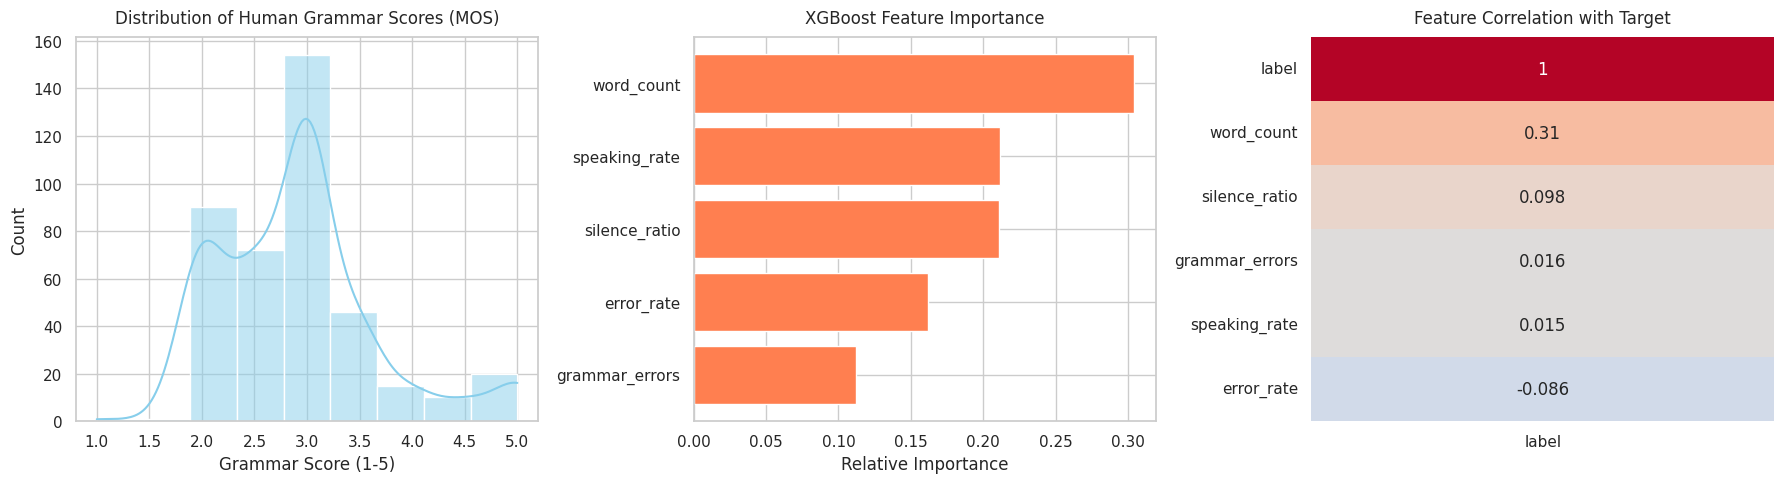


COMPULSORY TRAINING RMSE: 0.5521


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

# Set a professional visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# --- Plot 1: Target Distribution ---
plt.subplot(1, 3, 1)
sns.histplot(df['label'], bins=9, kde=True, color='skyblue')
plt.title('Distribution of Human Grammar Scores (MOS)', fontsize=12, pad=10)
plt.xlabel('Grammar Score (1-5)')
plt.ylabel('Count')

# --- Plot 2: Feature Importance ---
plt.subplot(1, 3, 2)
# Get importance from our trained master model
importances = final_model.feature_importances_
# Sort features by importance
sorted_idx = np.argsort(importances)

plt.barh(range(len(sorted_idx)), importances[sorted_idx], color='coral', align='center')
plt.yticks(range(len(sorted_idx)), [features[i] for i in sorted_idx])
plt.title('XGBoost Feature Importance', fontsize=12, pad=10)
plt.xlabel('Relative Importance')

# --- Plot 3: Correlation Heatmap ---
plt.subplot(1, 3, 3)
# Calculate correlations between our features and the target label
corr_matrix = df[['label'] + features].corr()
sns.heatmap(corr_matrix[['label']].sort_values(by='label', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.title('Feature Correlation with Target', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

# Print the compulsory training RMSE requirement!
print("\n" + "="*60)
# Calculate RMSE on the entire training set (as explicitly requested by the rules)
train_preds = final_model.predict(X)
compulsory_train_rmse = np.sqrt(mean_squared_error(y, train_preds))
print(f"COMPULSORY TRAINING RMSE: {compulsory_train_rmse:.4f}")
print("="*60)

In [17]:
import os
import pandas as pd
import numpy as np
import librosa
from faster_whisper import WhisperModel
import language_tool_python
from tqdm.notebook import tqdm
import xgboost as xgb

print("Starting Final Inference Pipeline for Test Data...")

# 1. Dynamically find test.csv
test_csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'test.csv' in files:
        test_csv_path = os.path.join(root, 'test.csv')
        break

if not test_csv_path:
    print("CRITICAL ERROR: Could not find test.csv anywhere!")
else:
    print(f"Found test.csv at: {test_csv_path}")
    test_df = pd.read_csv(test_csv_path)

    # 2. Setup our tools
    print("Loading models...")
    whisper_model = WhisperModel("base", device="cuda", compute_type="float16")
    grammar_tool = language_tool_python.LanguageTool('en-US')
    loaded_xgb = xgb.XGBRegressor()
    loaded_xgb.load_model("shl_grammar_xgboost.json")

    # 3. Find the exact Test Audio Directory
    test_audio_dir = None
    for root, dirs, files in os.walk('/kaggle/input'):
        # Looking for a known test file, or just checking the folder name
        if 'test' in root.split('/') and any(f.endswith('.wav') for f in files):
            test_audio_dir = root
            break

    if not test_audio_dir:
        print("CRITICAL ERROR: Could not find the test audio folder.")
    else:
        print(f"Found test audio folder at: {test_audio_dir}")
        
        # Initialize lists for features
        t_grammar_errors = []
        t_word_counts = []
        t_error_rates = []
        t_silence_ratios = []
        t_speaking_rates = []
        
        print(f"Processing {len(test_df)} Test Files (This will take a few minutes)...")
        for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
            fname = str(row['filename'])
            if not fname.endswith('.wav'):
                fname += '.wav'
                
            audio_path = os.path.join(test_audio_dir, fname)
            
            # Default fallback values if file is missing or corrupted
            g_errs, w_cnt, e_rate, s_ratio, spk_rate = 0, 0, 0, 0, 0
            
            if os.path.exists(audio_path):
                try:
                    # --- A. Text Pipeline ---
                    segments, _ = whisper_model.transcribe(audio_path, beam_size=5)
                    transcript = " ".join([segment.text for segment in segments])
                    
                    if transcript.strip():
                        matches = grammar_tool.check(transcript)
                        g_errs = len(matches)
                        w_cnt = len(transcript.split())
                        e_rate = g_errs / w_cnt if w_cnt > 0 else 0
                    
                    # --- B. Acoustic Pipeline ---
                    import warnings
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore") # hide those red audio warnings
                        y, sr = librosa.load(audio_path, sr=16000)
                        
                    total_duration = librosa.get_duration(y=y, sr=sr)
                    non_mute_intervals = librosa.effects.split(y, top_db=30)
                    
                    speaking_duration = sum([(interval[1] - interval[0])/sr for interval in non_mute_intervals])
                    silence_duration = total_duration - speaking_duration
                    
                    s_ratio = silence_duration / total_duration if total_duration > 0 else 0
                    spk_rate = w_cnt / speaking_duration if speaking_duration > 0 else 0
                    
                except Exception as e:
                    pass # Use defaults on failure
                    
            # Append features
            t_grammar_errors.append(g_errs)
            t_word_counts.append(w_cnt)
            t_error_rates.append(e_rate)
            t_silence_ratios.append(s_ratio)
            t_speaking_rates.append(spk_rate)

        # 4. Create the final test feature dataframe
        test_features_df = pd.DataFrame({
            'grammar_errors': t_grammar_errors,
            'word_count': t_word_counts,
            'error_rate': t_error_rates,
            'silence_ratio': t_silence_ratios,
            'speaking_rate': t_speaking_rates
        })
        
        # 5. Generate Predictions!
        print("Generating predictions...")
        test_predictions = loaded_xgb.predict(test_features_df)
        
        # Ensure predictions stay within the 0 to 5 bounds requested by the rules
        test_predictions = np.clip(test_predictions, 0, 5)
        
        # 6. Format Submission File
        submission = pd.DataFrame({
            'filename': test_df['filename'],
            'label': test_predictions
        })
        
        submission.to_csv('submission.csv', index=False)
        print("\nSUCCESS! submission.csv is ready for the leaderboard.")
        display(submission.head())

Starting Final Inference Pipeline for Test Data...
Found test.csv at: /kaggle/input/competitions/shl-audio-scoring-challenge/dataset/csvs/test.csv
Loading models...
Found test audio folder at: /kaggle/input/competitions/shl-audio-scoring-challenge/dataset/audios/test
Processing 197 Test Files (This will take a few minutes)...


  0%|          | 0/197 [00:00<?, ?it/s]

Generating predictions...

SUCCESS! submission.csv is ready for the leaderboard.


,filename,label
0,audio_141,2.628828
1,audio_114,2.841009
2,audio_17,2.497157
3,audio_76,3.531602
4,audio_156,2.791925
